In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_excel('dados_frutas.xlsx')

In [ ]:
df

,Arredondada,Suculenta,Vermelha,Doce,Fruta
0,0,1,1,1,Morango
1,1,0,0,0,Limão
2,1,1,0,1,Pera
3,0,0,0,1,Banana
4,1,1,1,1,Cereja
5,1,1,1,0,Tomate
6,1,1,1,1,Maçã


In [ ]:
X = df.drop('Fruta', axis=1)
y = df.Fruta

In [ ]:
X

,Arredondada,Suculenta,Vermelha,Doce
0,0,1,1,1
1,1,0,0,0
2,1,1,0,1
3,0,0,0,1
4,1,1,1,1
5,1,1,1,0
6,1,1,1,1


In [ ]:
y

,Fruta
0,Morango
1,Limão
2,Pera
3,Banana
4,Cereja
5,Tomate
6,Maçã


In [ ]:
df.columns

Index(['Arredondada', 'Suculenta', 'Vermelha', 'Doce', 'Fruta'], dtype='object')

In [ ]:
features = df.columns

Machine learning

In [ ]:
from sklearn import tree

In [ ]:
tree1 = tree.DecisionTreeClassifier(random_state=42) #random state escolhe a seed da minha arvore de decisão e garante a reprodutiblidade. Não
#usar nenhum número no parametro, significa que o modelo não vai ter a mesma "Aleatoridade" dos resultados todas as vezes, gerando ruídos.Usar
# um número garante a reprodutibilidade do mesmo modelo em cenários diferentes

In [ ]:
tree1.fit(X, y)

DecisionTreeClassifier(random_state=42)

In [ ]:
tree1.predict([[0,0,0,0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['Banana'], dtype=object)

plotando a arvore de decisão

[Text(0.4090909090909091, 0.875, 'Arredondada <= 0.5\ngini = 0.857\nsamples = 7\nvalue = [1, 1, 1, 1, 1, 1, 1]\nclass = Banana'),
 Text(0.18181818181818182, 0.625, 'Suculenta <= 0.5\ngini = 0.5\nsamples = 2\nvalue = [1, 0, 0, 0, 1, 0, 0]\nclass = Banana'),
 Text(0.29545454545454547, 0.75, 'True  '),
 Text(0.09090909090909091, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [1, 0, 0, 0, 0, 0, 0]\nclass = Banana'),
 Text(0.2727272727272727, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 0, 0, 1, 0, 0]\nclass = Morango'),
 Text(0.6363636363636364, 0.625, 'Vermelha <= 0.5\ngini = 0.8\nsamples = 5\nvalue = [0, 1, 1, 1, 0, 1, 1]\nclass = Cereja'),
 Text(0.5227272727272727, 0.75, '  False'),
 Text(0.45454545454545453, 0.375, 'Suculenta <= 0.5\ngini = 0.5\nsamples = 2\nvalue = [0, 0, 1, 0, 0, 1, 0]\nclass = Limão'),
 Text(0.36363636363636365, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1, 0, 0, 0, 0]\nclass = Limão'),
 Text(0.5454545454545454, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 0, 0

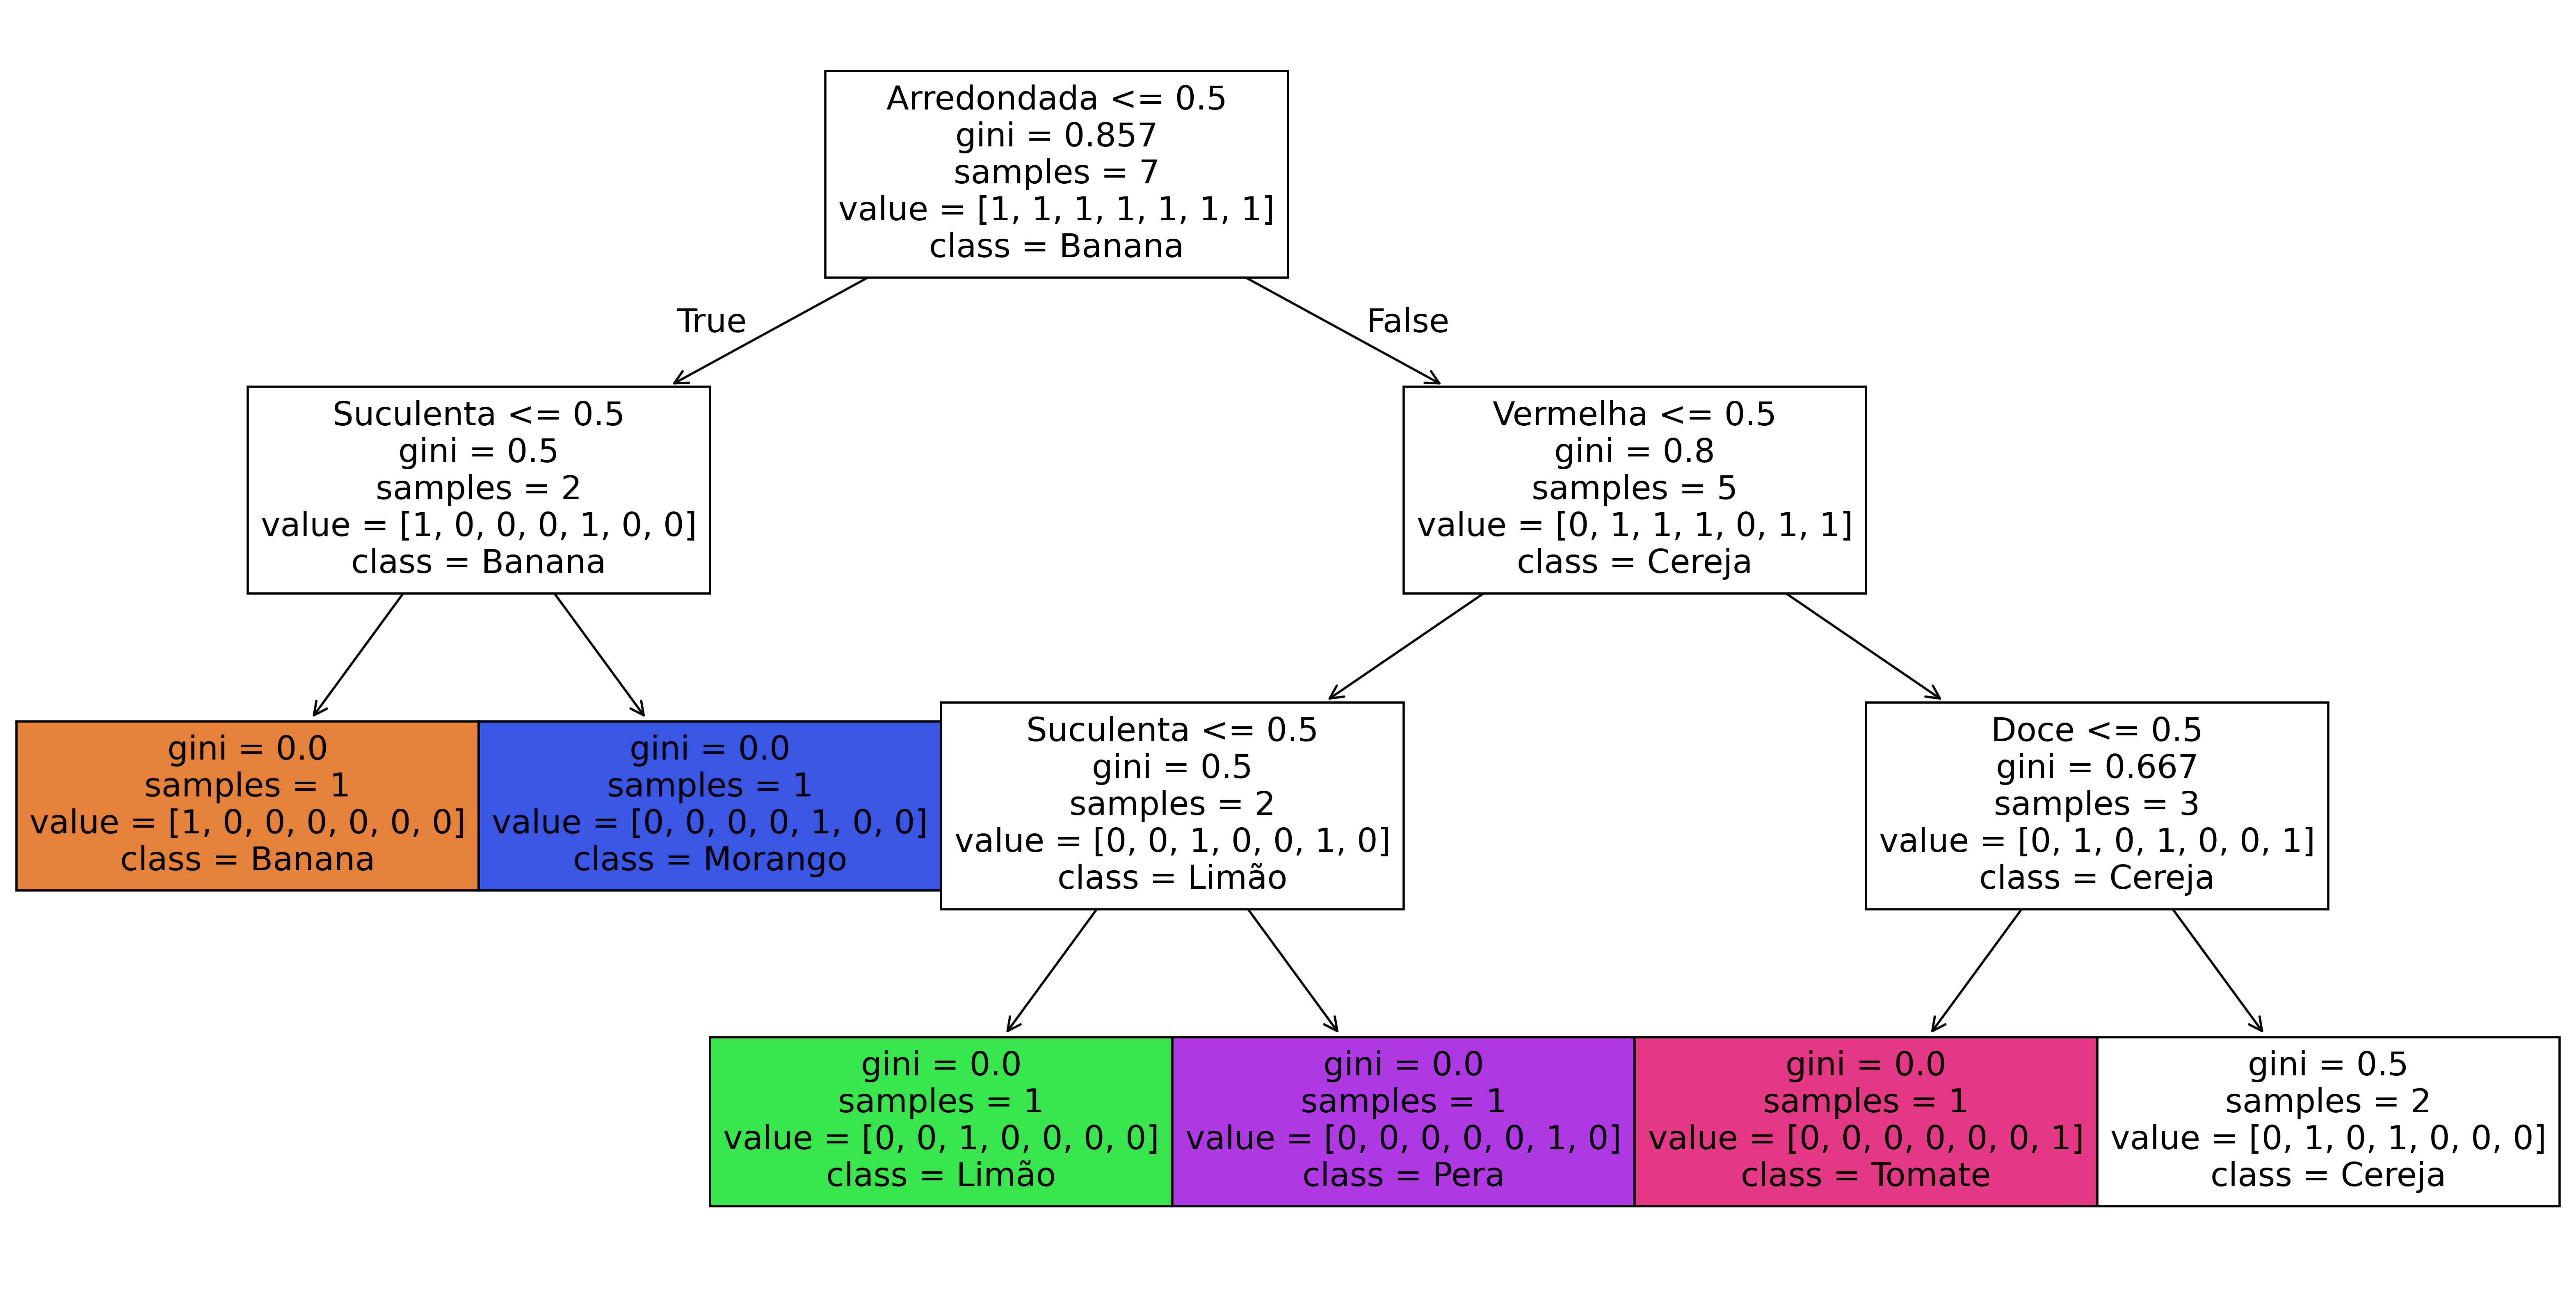

In [ ]:
plt.figure(figsize=(20,10), dpi=(400))
tree.plot_tree(tree1, feature_names=features, class_names=tree1.classes_, filled= True) #ploto a  arvore de decisão. Como parametro, passo a pró
#pria arvore treinada, depois o nome das features, o nome das classes (variaveis do target a serem classificadas)

No primeiro nó da árvore, é mostrada as classes passadas (em um array e quantos valores eu tenho por classe, nesse caso como usamos a variável classes, automaticamente tiramos duplicatas), acima em sample, temos o total de classes possíveis naquele nó (no primeiro nó, sempre temos todas as classes possíveis, e a predição sempre vai ser a primeira classe em ordem alfabética). Na primeira linha, temos a primeira pergunta da arvore (nesse caso, se a variável arredondada é menor ou igual a 0.5. Como nossa variável arredondada só tem valores 0 ou 1, o valor menor ou igual que  0.5 significa que a fruta NÃO é arredondada). Para cada valor True ou false, é gerado um novo nó com menos possibilidades que o nó anterior.

In [ ]:
tree1.predict_proba([[0,0,0,0]]) #Com predict proba, recebemos qual a probabilidade do valor predito ser uma das nossas classes. Indo de 0 a 1

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([[1., 0., 0., 0., 0., 0., 0.]])

In [ ]:
proba = tree1.predict_proba([[0,0,0,0]])[0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
pd.Series(proba, index=tree1.classes_)

,0
Banana,1.0
Cereja,0.0
Limão,0.0
Maçã,0.0
Morango,0.0
Pera,0.0
Tomate,0.0


In [ ]:
proba = tree1.predict_proba([[1,1,1,1]])[0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
pd.Series(proba, index=tree1.classes_)

,0
Banana,0.0
Cereja,0.5
Limão,0.0
Maçã,0.5
Morango,0.0
Pera,0.0
Tomate,0.0
